## 1. Environment Setup & Data Upload
This notebook implements the Transfer Matrix Method (TMM) to simulate the optical properties of a multilayer Perovskite Solar Cell. The methodology closely follows the framework discussed in the research paper:
**"TMM-Sim: A versatile tool for optical simulation of thin-film solar cells"** *(Computer Physics Communications, 2024)* - [Read Paper Here (DOI: 10.1016/j.cpc.2024.109206)](https://doi.org/10.1016/j.cpc.2024.109206).

**What this cell does:**
1. Installs the `tmm` Python package, which solves Maxwell's equations for light propagating through thin, parallel layers of optical media.
2. Prompts the user to upload the input dataset (`cleaned_estimated_optical_constants.csv`).
**Inputs required in the CSV:** The wavelength range (300 nm to 900 nm) alongside the wavelength-dependent refractive index ($n$) and extinction coefficient ($k$) for every material in the device stack.

In [1]:
# Install the Transfer Matrix Method package
!pip install tmm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tmm
from scipy.integrate import simpson
from google.colab import files

# Upload your 'cleaned_estimated_optical_constants.csv'
print("Please upload: 'cleaned_estimated_optical_constants.csv'")
uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 10.8 MB/s eta 0:00:00
Please upload: 'cleaned_estimated_optical_constants.csv'


Saving cleaned_estimated_optical_constants.csv to cleaned_estimated_optical_constants.csv


## 2. Core TMM Calculations & Data Export
In this cell, we define the physical structure of our solar cell stack: **Air $\rightarrow$ FTO $\rightarrow$ ETL $\rightarrow$ Perovskite $\rightarrow$ HTL $\rightarrow$ Metal contact**.

**How it works:**
* **Input Parameters:** We specify the physical thickness of each layer in nanometers ($d\_list$). The infinite incident medium (Air) and exit medium (Metal back-contact) are assigned `np.inf` thickness.
* **Complex Refractive Index:** For every wavelength, the algorithm computes the complex refractive index $\tilde{N} = n + i k$ using the optical constants we uploaded.
* **TMM Execution:** We run the Coherent Transfer Matrix Method (`tmm.coh_tmm`) for unpolarized ('s') light at standard normal incidence ($0^{\circ}$ angle).
* **Output:** The algorithm calculates the interference of forward and backward traveling light waves to deduce the exact fraction of incident light absorbed within each specific layer.
* **Export:** The calculated reflectance and layer-by-layer absorption profiles are saved into a new CSV file (`tmm_absorption_results.csv`) and automatically downloaded for use in electrical simulation software like SCAPS-1D.

Running Core TMM Optical Calculations...
✅ Calculation Complete! Saving and downloading: tmm_absorption_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

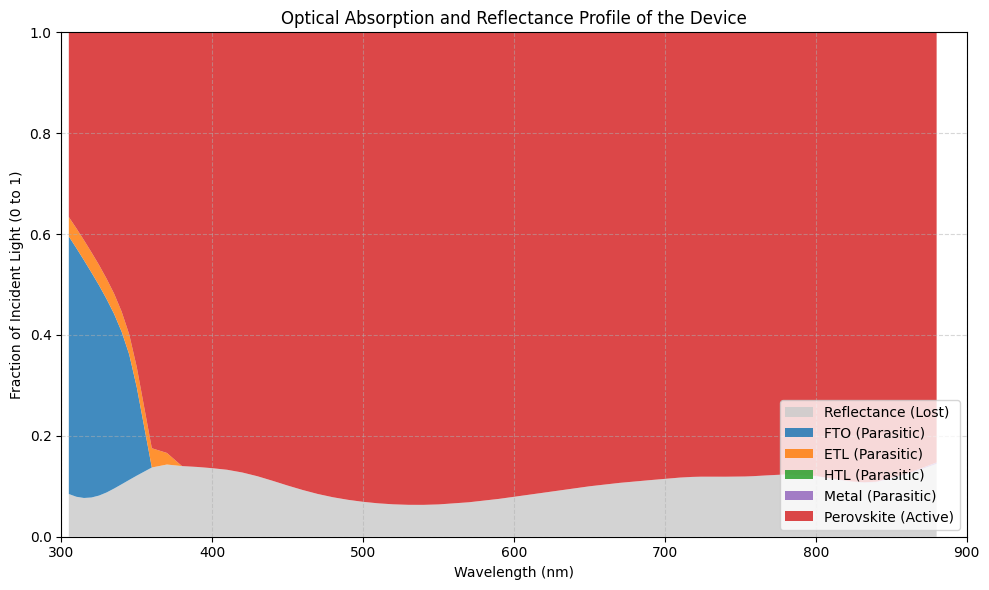

In [2]:
# 1. Load Data
df = pd.read_csv('cleaned_estimated_optical_constants.csv')
df = df[(df['wavelength_nm'] >= 300) & (df['wavelength_nm'] <= 900)].reset_index(drop=True)
wavelengths = df['wavelength_nm'].values

# 2. Define Layer Thicknesses (in nm)
# Structure: Air (incident) -> FTO -> ETL -> PEROVSKITE -> HTL -> Metal
d_list = [np.inf, 200, 20, 1200, 20, np.inf]

# 3. Setup Storage Arrays
R_list, A_FTO, A_ETL, A_PERO, A_HTL, A_METAL = [], [], [], [], [], []

print("Running Core TMM Optical Calculations...")

# 4. Iterate over wavelengths and calculate Reflectance/Transmittance/Absorption
for idx, row in df.iterrows():
    wl = row['wavelength_nm']

    # Define Complex Refractive Indices: N = n + i*k
    n_list = [
        1.0 + 0j, # Air
        row['n_FTO'] + 1j * row['k_FTO'],
        row['n_ETL'] + 1j * row['k_ETL'],
        row['n_PEROVSKITE'] + 1j * row['k_PEROVSKITE'],
        row['n_HTL'] + 1j * row['k_HTL'],
        row['n_METAL'] + 1j * row['k_METAL']
    ]

    # Execute Coherent TMM for 's' polarization at normal incidence (0 degrees)
    res = tmm.coh_tmm('s', n_list, d_list, th_0=0, lam_vac=wl)

    # Calculate fraction of light absorbed in each specific layer
    absorp = tmm.absorp_in_each_layer(res)

    R_list.append(res['R'])
    A_FTO.append(absorp[1])
    A_ETL.append(absorp[2])
    A_PERO.append(absorp[3]) # Perovskite is index 3
    A_HTL.append(absorp[4])
    A_METAL.append(absorp[5])

# Store results in a DataFrame
df_tmm = pd.DataFrame({
    'Wavelength_nm': wavelengths, 'Reflectance': R_list,
    'Abs_FTO': A_FTO, 'Abs_ETL': A_ETL,
    'Abs_PEROVSKITE': A_PERO, 'Abs_HTL': A_HTL, 'Abs_METAL': A_METAL
})

# 5. SAVE AND DOWNLOAD THE TMM RESULTS CSV
csv_filename = 'tmm_absorption_results.csv'
df_tmm.to_csv(csv_filename, index=False)
print(f"✅ Calculation Complete! Saving and downloading: {csv_filename}")
files.download(csv_filename)

# 6. Plot the Stacked Absorption Spectra
plt.figure(figsize=(10, 6))
plt.stackplot(wavelengths, df_tmm['Reflectance'], df_tmm['Abs_FTO'],
              df_tmm['Abs_ETL'], df_tmm['Abs_HTL'], df_tmm['Abs_METAL'], df_tmm['Abs_PEROVSKITE'],
              labels=['Reflectance (Lost)', 'FTO (Parasitic)', 'ETL (Parasitic)', 'HTL (Parasitic)', 'Metal (Parasitic)', 'Perovskite (Active)'],
              colors=['#cccccc', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728'], alpha=0.85)

plt.title('Optical Absorption and Reflectance Profile of the Device')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Fraction of Incident Light (0 to 1)')
plt.xlim(300, 900)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Theoretical Photocurrent Generation and Parasitic Losses
Optical absorption data alone is not enough to predict device efficiency. We must map our absorption data against the actual solar spectrum the device will be exposed to.

**How it works:**
1.  **Solar Spectrum Modeling:** We mathematically approximate the standard AM 1.5G (1 Sun) solar spectrum using Planck's Blackbody radiation law (at 5800K) and normalize it to exactly $1000 \ W/m^2$ over our 300–900 nm range.
2.  **Photon Flux Conversion:** We convert the solar spectral irradiance ($W/m^2/nm$) into a photon flux, which gives us the number of photons hitting the device per second at each wavelength.
3.  **Numerical Integration:** Assuming an Internal Quantum Efficiency (IQE) of 100% (every absorbed photon in the active layer yields one electron-hole pair), we integrate the Perovskite absorption against the photon flux to calculate the **Maximum Theoretical Short-Circuit Current ($J_{max}$)** in $mA/cm^2$.
4.  **Parasitic Loss Analysis:** We apply the same integration to the non-active layers (FTO, ETL, HTL) and reflection to quantify exactly how many $mA/cm^2$ of potential current are lost to parasitic optical effects.

   OPTICAL ELECTRICAL PERFORMANCE (AM 1.5G 1 Sun)
   Assuming 100% Internal Quantum Efficiency (IQE)
Maximum Theoretical Photocurrent (J_max): 41.22 mA/cm²
-------------------------------------------------------
Parasitic Loss - Reflection:              4.75 mA/cm²
Parasitic Loss - FTO Absorption:          0.61 mA/cm²
Parasitic Loss - ETL Absorption:          0.10 mA/cm²
Parasitic Loss - HTL Absorption:          0.00 mA/cm²
Parasitic Loss - Metal Absorption:        0.01 mA/cm²


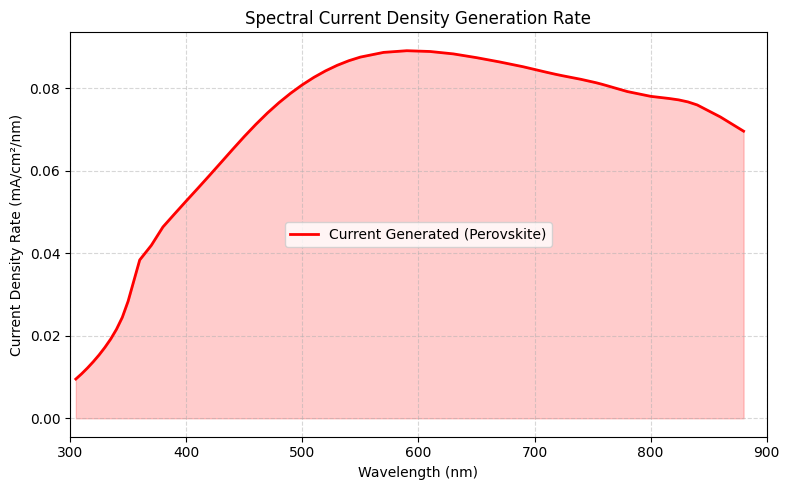

In [3]:
# 1. Physics Constants
q = 1.602e-19       # Elementary charge (C)
h = 6.626e-34       # Planck's constant (J*s)
c = 3.0e8           # Speed of light (m/s)
k_B = 1.38e-23      # Boltzmann constant (J/K)
T_sun = 5800        # Solar temperature approximation (K)

wl_m = wavelengths * 1e-9 # Convert nm to meters

# 2. Approximate AM1.5G 1 Sun Spectrum using Planck's Blackbody Law
spectral_irradiance = (2 * h * c**2 / wl_m**5) * (1 / (np.exp(h * c / (wl_m * k_B * T_sun)) - 1))
total_power = simpson(spectral_irradiance, x=wavelengths)
spectral_irradiance = spectral_irradiance * (1000 / total_power) # Scale exactly to 1000 W/m^2

# 3. Convert Irradiance to Photon Flux, then to Current Density Generation Factor (mA/cm^2/nm)
photon_energy = h * c / wl_m
photon_flux = spectral_irradiance / photon_energy
current_factor = q * photon_flux * (1000 / 10000) # Convert A/m^2 to mA/cm^2

# 4. Integrate across the spectrum to get total mA/cm^2 generated/lost per layer
J_pero = simpson(current_factor * df_tmm['Abs_PEROVSKITE'], x=wavelengths)
J_loss_refl = simpson(current_factor * df_tmm['Reflectance'], x=wavelengths)
J_loss_FTO = simpson(current_factor * df_tmm['Abs_FTO'], x=wavelengths)
J_loss_ETL = simpson(current_factor * df_tmm['Abs_ETL'], x=wavelengths)
J_loss_HTL = simpson(current_factor * df_tmm['Abs_HTL'], x=wavelengths)
J_loss_METAL = simpson(current_factor * df_tmm['Abs_METAL'], x=wavelengths)

# 5. Print Results
print("="*55)
print("   OPTICAL ELECTRICAL PERFORMANCE (AM 1.5G 1 Sun)")
print("   Assuming 100% Internal Quantum Efficiency (IQE)")
print("="*55)
print(f"Maximum Theoretical Photocurrent (J_max): {J_pero:.2f} mA/cm²")
print("-" * 55)
print(f"Parasitic Loss - Reflection:              {J_loss_refl:.2f} mA/cm²")
print(f"Parasitic Loss - FTO Absorption:          {J_loss_FTO:.2f} mA/cm²")
print(f"Parasitic Loss - ETL Absorption:          {J_loss_ETL:.2f} mA/cm²")
print(f"Parasitic Loss - HTL Absorption:          {J_loss_HTL:.2f} mA/cm²")
print(f"Parasitic Loss - Metal Absorption:        {J_loss_METAL:.2f} mA/cm²")
print("="*55)

# 6. Plot Spectral Current Generation
plt.figure(figsize=(8, 5))
plt.plot(wavelengths, current_factor * df_tmm['Abs_PEROVSKITE'], color='red', linewidth=2, label='Current Generated (Perovskite)')
plt.fill_between(wavelengths, 0, current_factor * df_tmm['Abs_PEROVSKITE'], color='red', alpha=0.2)
plt.title('Spectral Current Density Generation Rate')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Current Density Rate (mA/cm²/nm)')
plt.xlim(300, 900)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Internal Optical Electric Field Profile
Understanding how light propagates and interferes inside the ultra-thin films of a solar cell requires position-resolved mapping. Due to the differences in refractive indices between layers, light reflects at every interface, creating standing waves within the device.

**How it works:**
* **Depth Mapping:** The algorithm splits the physical depth ($x$) of the entire device into tiny slices (2 nm resolution).
* **Electric Field Amplitude:** For a set of given target wavelengths (e.g., 400 nm, 500 nm, 600 nm, 700 nm), it queries the TMM algorithm to calculate the 3D complex electric field components ($E_x, E_y, E_z$) at each specific depth $x$.
* **Intensity Calculation:** We calculate the normalized electric field intensity $|E(x)|^2$, which correlates directly to the spatial generation rate of excitons (electron-hole pairs) at that exact coordinate inside the cell.
* **Interpretation:** An ideally optimized device will show the highest $|E(x)|^2$ peaks localized entirely within the thick Perovskite layer, rather than decaying heavily in the FTO or ETL layers.

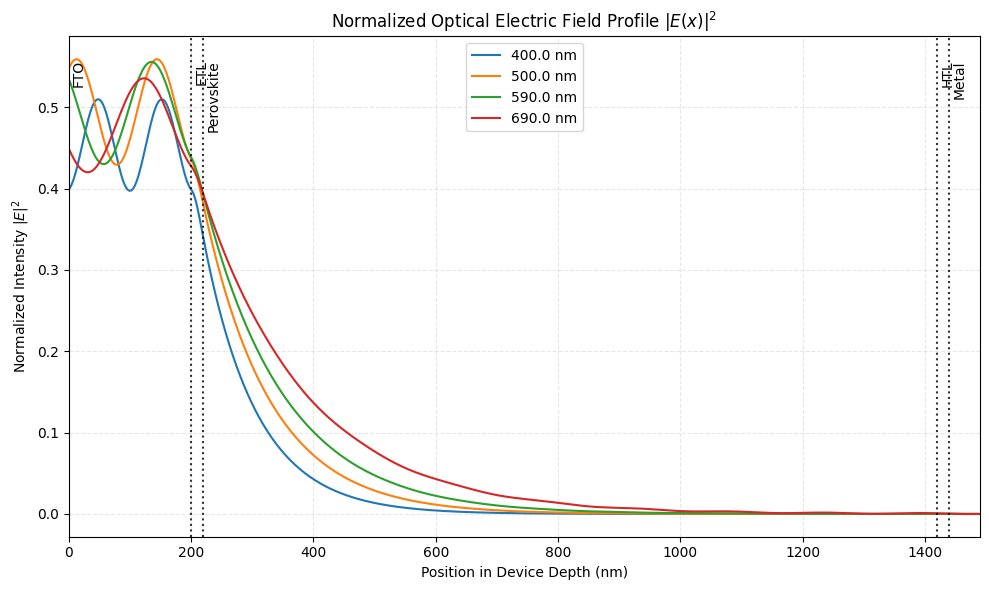

In [5]:
# 1. Define specific wavelengths to analyze (as done in literature)
target_wls = [400, 500, 600, 700]
depth_resolution = 2 # nm step size for spatial mapping

# 2. Extract finite layer thicknesses to determine total simulation depth
finite_thicknesses = d_list[1:-1] # FTO, ETL, PERO, HTL (excludes Air and Metal)
total_finite_depth = sum(finite_thicknesses)
total_sim_depth = total_finite_depth + 50 # Add 50nm penetration into the metal layer
depths = np.arange(0, total_sim_depth, depth_resolution)

plt.figure(figsize=(10, 6))

# 3. Calculate Electric Field Intensity at each depth
for wl_target in target_wls:
    idx = (np.abs(wavelengths - wl_target)).argmin() # Find closest simulated wavelength
    row = df.iloc[idx]

    n_list = [
        1.0 + 0j,
        row['n_FTO'] + 1j * row['k_FTO'],
        row['n_ETL'] + 1j * row['k_ETL'],
        row['n_PEROVSKITE'] + 1j * row['k_PEROVSKITE'],
        row['n_HTL'] + 1j * row['k_HTL'],
        row['n_METAL'] + 1j * row['k_METAL']
    ]

    # Run coherent TMM for this specific wavelength
    res = tmm.coh_tmm('s', n_list, d_list, th_0=0, lam_vac=row['wavelength_nm'])

    E_squared = []
    for d in depths:
        # ---- BUG FIX: Correctly identify the layer index and internal distance ----
        layer_idx = 0
        dist_in_layer = 0
        z = 0

        # Check finite layers (indices 1 through 4)
        for i in range(1, len(d_list) - 1):
            if d < z + d_list[i]:
                layer_idx = i
                dist_in_layer = d - z
                break
            z += d_list[i]

        # If the depth 'd' exceeds all finite layers, it falls into the final Metal layer (index 5)
        if layer_idx == 0:
            layer_idx = len(d_list) - 1
            dist_in_layer = d - z
        # --------------------------------------------------------------------------

        # Resolve the E-field at this position
        pos_res = tmm.position_resolved(layer_idx, dist_in_layer, res)

        # Handle tmm v0.2.0+ which outputs Ex, Ey, Ez vectors directly
        if 'Ex' in pos_res:
            E_mag_sq = np.abs(pos_res['Ex'])**2 + np.abs(pos_res['Ey'])**2 + np.abs(pos_res['Ez'])**2
        else:
            E_mag_sq = np.abs(pos_res['vw'] + pos_res['bw'])**2

        E_squared.append(E_mag_sq)

    plt.plot(depths, E_squared, label=f'{row["wavelength_nm"]} nm', linewidth=1.5)

# 4. Format plot and add layer interface boundary lines
layer_names = ['FTO', 'ETL', 'Perovskite', 'HTL', 'Metal']
plot_boundaries = np.cumsum(finite_thicknesses)

# Draw interface dotted lines
for b in plot_boundaries:
    plt.axvline(x=b, color='black', linestyle=':', alpha=0.8)

# Add text labels perfectly positioned at the start of each layer
label_positions = [0] + list(plot_boundaries)
for i in range(len(layer_names)):
    x_pos = label_positions[i]
    plt.text(x_pos + 5, plt.ylim()[1]*0.95, layer_names[i], rotation=90, verticalalignment='top', fontsize=10)

plt.title('Normalized Optical Electric Field Profile $|E(x)|^2$')
plt.xlabel('Position in Device Depth (nm)')
plt.ylabel('Normalized Intensity $|E|^2$')
plt.xlim(0, total_sim_depth)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()